In [289]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
import numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow
from tensorflow import keras

In [290]:
dataset = pd.read_csv('heart_disease_uci.csv')
conversion_tables = {}
conversion_tables['sex'] = {'Male' : 0,
                            "Female" : 1}
conversion_tables['fbs'] = {True : 1,
                             False : 0}
conversion_tables['exang'] = conversion_tables['fbs']

#to build roc curve for my learning, result is mapped to only 0 and 1
#model is also very bad if there are more than 2 categories
BINARY_RESULT = True
if BINARY_RESULT:
    conversion_tables['num'] = {0 : 0, 
                                1 : 0,
                                2 : 1,
                                3 : 1,
                                4 : 1 }

for feature, mapping in conversion_tables.items():
    dataset[feature] = dataset[feature].map(mapping)


#Feature 'dataset' has somewhat misleading name, it is basically person's origin
columns_for_one_hot = ['dataset', 'cp', 'restecg', 'slope', 'thal']

for feature in columns_for_one_hot:
    origin_columns = pd.get_dummies(dataset[feature], drop_first=True).astype(int)
    dataset = pd.concat([dataset, origin_columns], axis=1)
    dataset = dataset.drop(columns = [feature])

dataset = dataset.drop(columns=['id'])

In [291]:
dataset_cleaned = dataset.dropna()

In [292]:
features = dataset_cleaned.columns.tolist()
features.remove('num')

X = dataset_cleaned[features]
y = dataset_cleaned['num']




X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True)

#Uncomment the next line to fill in missing values
'''for feature in dataset.columns:
    X[feature] = dataset[feature].fillna(dataset[feature].mean())'''

#SCALING
scaler = StandardScaler()
#don't scale categorical data and strings replaced with 1/0
#scale only numerical data (e.g  age)
#features_for_scaling = list(set(features) -  set(columns_for_one_hot) - set(conversion_tables.keys()))
features_for_scaling = ['age', 'trestbps', 'chol', 'thalch'] 
X_train[features_for_scaling] = scaler.fit_transform(X_train[features_for_scaling])
X_test[features_for_scaling] = scaler.transform(X_test[features_for_scaling])

choices = np.logspace(-4, 4, 20)
accuracies = []
logreg = LogisticRegression(max_iter=100)
for C in choices:
    logreg.set_params(C = C)
    logreg.fit(X_train, y_train)
    y_pred = logreg.predict(X_test)
    accuracy = metrics.accuracy_score(y_true=y_test, y_pred=y_pred)
    accuracies.append(accuracy)


plt.plot(np.log10(choices), accuracies)
plt.show()

In [293]:
#choose a model to use
#models = ["neuralnet", "logreg"]
method = "logreg"
#Logistic regression gives moderate-to-good predictive power
if method == "logreg":
    logreg = LogisticRegression(max_iter=100, C = 0.1)
    logreg.fit(X_train, y_train)
    probabilities = logreg.predict_proba(X_test)
    y_pred = logreg.predict(X_test)

#Neural network is uneffective for such small dataset
#Essentially it labels everyone as healthy
elif method == "neuralnet":
    n_features = len(X_train.columns)
    n_classes = len(dataset_cleaned["num"].unique())
    nn = keras.models.Sequential([
        keras.layers.Input(shape = (n_features,)),
        keras.layers.Dense(20, activation="sigmoid"),
        keras.layers.Dense(10, activation="relu"),
        keras.layers.Dense(n_classes, activation="softmax")
    ])
    nn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    nn.fit(X_train, y_train, epochs=2, batch_size=6)
    probabilities = nn.predict(X_test)
    #print(probabilities[1])
    y_pred = np.argmax(probabilities, axis=1)
    #print(y_pred[1])

In [294]:

accuracy  = metrics.accuracy_score(y_true=y_test, y_pred=y_pred)
conf_mat = metrics.confusion_matrix(y_true=y_test, y_pred=y_pred)
print(f'{accuracy = }')
print(f'{conf_mat = }')
if BINARY_RESULT:
    print(f'Specificity: {metrics.recall_score(y_true=y_test, y_pred=y_pred, pos_label=0)}')
    
    print('-'*100)
    print(f'Precision: {metrics.precision_score(y_true=y_test, y_pred=y_pred)}')
    print(f'Sensitivity: {metrics.recall_score(y_true=y_test, y_pred=y_pred, pos_label=1)}')
    print(f'F1 score: {metrics.f1_score(y_true=y_test, y_pred=y_pred)}')
    print('-'*100)

    #Extracting probabilities of num == 1  
    probabilities_of_class_1 = [probability[1] for probability in probabilities]
    print(f'AUC-ROC score: {metrics.roc_auc_score(y_test, probabilities_of_class_1)}')

accuracy = 0.8289473684210527
conf_mat = array([[51,  5],
       [ 8, 12]])
Specificity: 0.9107142857142857
----------------------------------------------------------------------------------------------------
Precision: 0.7058823529411765
Sensitivity: 0.6
F1 score: 0.6486486486486487
----------------------------------------------------------------------------------------------------
AUC-ROC score: 0.90625


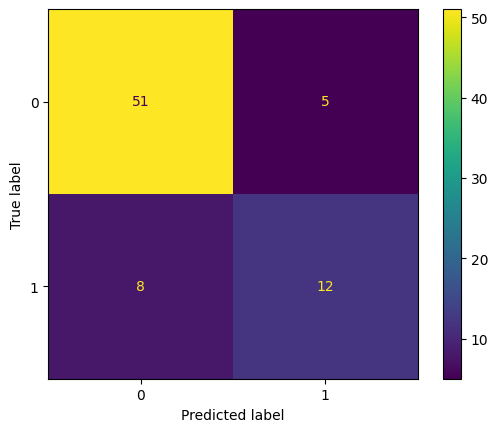

In [295]:
conf_mat_gui = metrics.ConfusionMatrixDisplay(confusion_matrix=conf_mat)

conf_mat_gui.plot()
plt.show()

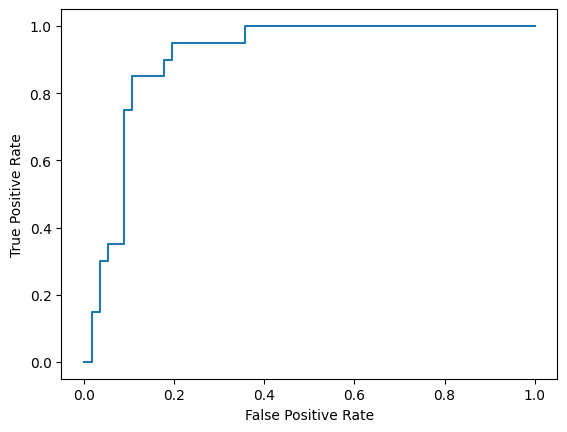

In [296]:
if BINARY_RESULT:
    def plot_roc_curve(true_y, y_prob):
        fpr, tpr, thresholds =  metrics.roc_curve(true_y, y_prob)
        plt.plot(fpr, tpr)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')

    
    plot_roc_curve(y_test, probabilities_of_class_1)
    plt.show()
    

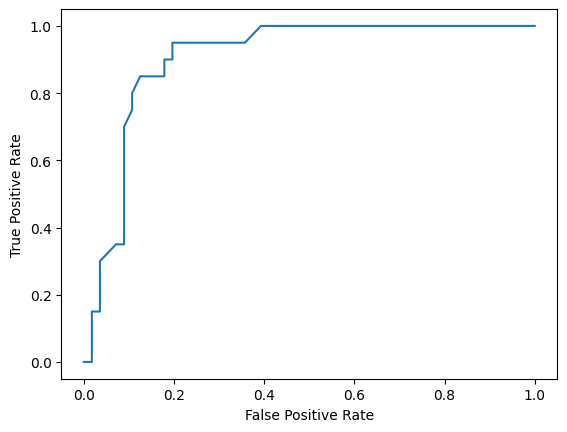

In [297]:
if BINARY_RESULT: 
    #My own ROC curve
    thresholds = np.arange(0, 1.01, 0.01)
    fpr_values = []
    tpr_values = []
    for threshold in thresholds:
        classes = probabilities_of_class_1 > threshold
        tpr = metrics.recall_score(y_test, classes, pos_label=1)
        fpr = 1 - metrics.recall_score(y_true=y_test, y_pred=classes, pos_label=0)
        fpr_values.append(fpr)
        tpr_values.append(tpr)

    plt.plot(fpr_values, tpr_values)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()